# Import the necessary Libraries

In [10]:
#Import the necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Load and Explore Datset

In [11]:

# Load dataset to inspect structure
df = pd.read_csv(f"C:\\Users\\jkaru\\PSA-Translation-Project\\data\\psa_english_kiswahili_parallel_corpus.csv")
print("Shape:", df.shape)
print("\nColumns:", df.columns)
print("\nHead:")
print(df.head())
print("\nMissing values:")
print(df.isnull().sum())
print("\nInfo:")
print(df.info())

Shape: (50000, 6)

Columns: Index(['master_id', 'psa_id', 'domain', 'subcategory', 'psa_text',
       'kiswahili_text'],
      dtype='str')

Head:
          master_id     psa_id  domain                     subcategory  \
0  PSA_MASTER_00001  PSA_00001  Health  Disease Prevention and Control   
1  PSA_MASTER_00002  PSA_00002  Health               Healthcare Access   
2  PSA_MASTER_00003  PSA_00003  Health       Maternal and Child Health   
3  PSA_MASTER_00004  PSA_00004  Health         Public Health Campaigns   
4  PSA_MASTER_00005  PSA_00005  Health       Maternal and Child Health   

                                            psa_text  \
0  Seek official advice from World Health Organiz...   
1  Community health services warn that incorrect ...   
2  Choose healthy behaviours every day. Provide c...   
3  Ministry of Health advises school communities ...   
4  Good family planning begins with responsible a...   

                                      kiswahili_text  
0  Tafuta ushaur

# Visualisation EDA 

Domain Counts:
 domain
Health                 10000
Agriculture            10000
Education              10000
Security and Safety    10000
Governance             10000
Name: count, dtype: int64

Top Subcategories:
 subcategory
Maternal and Child Health             2939
Crime Prevention                      2751
Disease Prevention and Control        2547
Public Health Campaigns               1889
Healthcare Access                     1686
Disaster and Crisis Governance        1333
Public Service Delivery               1293
Livestock Health                      1286
Child Protection and School Safety    1283
Human Rights                          1282
Name: count, dtype: int64

Summary Statistics:
        en_word_count  sw_word_count  en_char_count  sw_char_count  \
count   50000.000000   50000.000000   50000.000000   50000.000000   
mean       12.095740      14.457600      88.419240      97.032220   
std         2.731469       3.553305      18.382848      22.301828   
min         3.00000

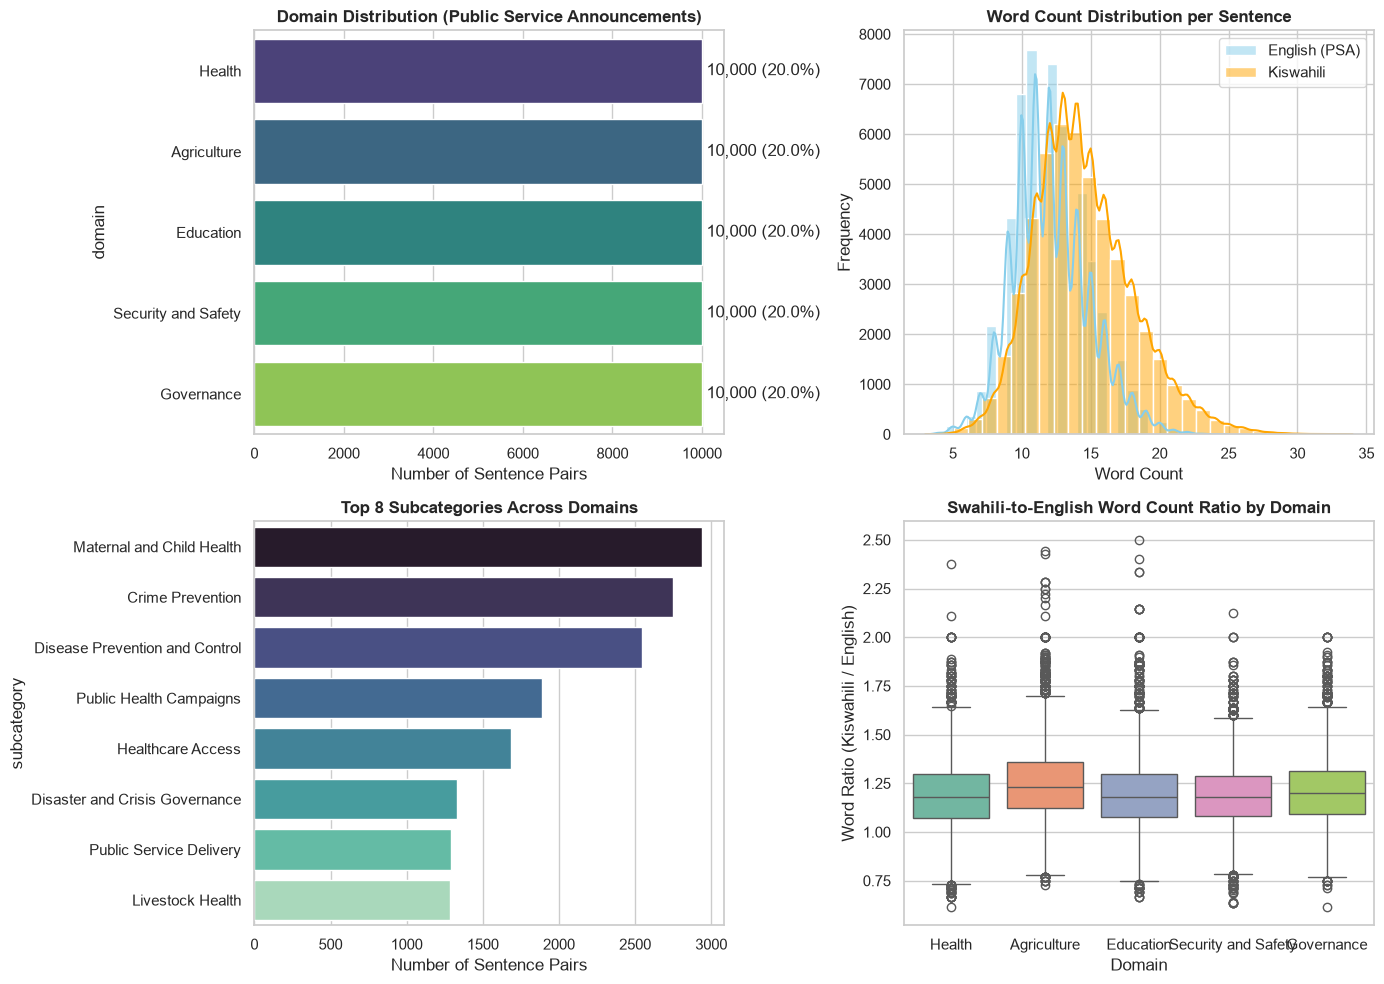

In [ ]:
# Set up matplotlib style
sns.set_theme(style="whitegrid")

# Calculate word counts and character counts
df['en_word_count'] = df['psa_text'].apply(lambda x: len(str(x).split()))
df['sw_word_count'] = df['kiswahili_text'].apply(lambda x: len(str(x).split()))
df['en_char_count'] = df['psa_text'].apply(lambda x: len(str(x)))
df['sw_char_count'] = df['kiswahili_text'].apply(lambda x: len(str(x)))
df['length_ratio'] = df['sw_word_count'] / df['en_word_count']

# Domain Distribution
domain_counts = df['domain'].value_counts()
print("Domain Counts:\n", domain_counts)

subcategory_counts = df['subcategory'].value_counts()
print("\nTop Subcategories:\n", subcategory_counts.head(10))

# Summary Statistics for Word Counts
stats = df[['en_word_count', 'sw_word_count', 'en_char_count', 'sw_char_count', 'length_ratio']].describe()
print("\nSummary Statistics:\n", stats)

# Vocabulary size (unique words lowercase)
en_vocab = set(word.strip(".,!?;:\"'()[]{}") for text in df['psa_text'] for word in text.lower().split())
sw_vocab = set(word.strip(".,!?;:\"'()[]{}") for text in df['kiswahili_text'] for word in text.lower().split())

print(f"\nEnglish Vocab Size: {len(en_vocab):,}")
print(f"Swahili Vocab Size: {len(sw_vocab):,}")

# Generate Visualization Plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Domain Distribution (Bar Chart)
sns.barplot(x=domain_counts.values, y=domain_counts.index, ax=axes[0,0], hue=domain_counts.index, palette="viridis")
axes[0,0].set_title("Domain Distribution (Public Service Announcements)", fontsize=12, fontweight='bold')
axes[0,0].set_xlabel("Number of Sentence Pairs")
for index, value in enumerate(domain_counts.values):
    axes[0,0].text(value + 100, index, f"{value:,} ({value/len(df)*100:.1f}%)", va='center')

# 2. Text Length Distribution (Word Count Histograms)
sns.histplot(df['en_word_count'], color="skyblue", label="English (PSA)", kde=True, ax=axes[0,1], bins=30)
sns.histplot(df['sw_word_count'], color="orange", label="Kiswahili", kde=True, ax=axes[0,1], bins=30)
axes[0,1].set_title("Word Count Distribution per Sentence", fontsize=12, fontweight='bold')
axes[0,1].set_xlabel("Word Count")
axes[0,1].set_ylabel("Frequency")
axes[0,1].legend()

# 3. Subcategory Top 8 Distribution
top_subcats = subcategory_counts.head(8)
sns.barplot(x=top_subcats.values, y=top_subcats.index, ax=axes[1,0], hue=top_subcats.index, palette="mako")
axes[1,0].set_title("Top 8 Subcategories Across Domains", fontsize=12, fontweight='bold')
axes[1,0].set_xlabel("Number of Sentence Pairs")

# 4. Length Ratio Distribution (Swahili / English)
sns.boxplot(x=df['domain'], y=df['length_ratio'], ax=axes[1,1], hue=df['domain'], palette="Set2")
axes[1,1].set_title("Swahili-to-English Word Count Ratio by Domain", fontsize=12, fontweight='bold')
axes[1,1].set_xlabel("Domain")
axes[1,1].set_ylabel("Word Ratio (Kiswahili / English)")

plt.tight_layout()
plt.savefig("eda_summary_plots.png", dpi=300)


The generated exploratory visualization reveals key structural attributes of the parallel dataset.
Key Insights from EDADomain Balance: Perfect domain balance across all 5 sectors (10,000 sentence pairs / 20.0% each).
Text Length & Expansion: Kiswahili text is on average 20% longer in word count and 9.7% longer in character count compared to English. This expansion ratio ($\approx 1.20$) is typical in English $\rightarrow$ Kiswahili translation.
Subcategory Focus: Top subcategories include Maternal and Child Health (2,939), Crime Prevention (2,751), and Disease Prevention and Control (2,547)

# Creation of Native-speaker validation subset

In [35]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split

# 1. Load Dataset
df = pd.read_csv(f"C:\\Users\\jkaru\\PSA-Translation-Project\\data\\psa_english_kiswahili_parallel_corpus.csv")
# 2. Text Normalization Pipeline
def normalize_text(text):
    if not isinstance(text, str):
        return ""
    # Standardize whitespace and remove unusual control characters
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['psa_text_clean'] = df['psa_text'].apply(normalize_text)
df['kiswahili_text_clean'] = df['kiswahili_text'].apply(normalize_text)

# 3. Create Cultural Terminology / Public Service Glossary
# Example domain-specific mapping dictionary
domain_glossary = {
    "Health": {"WHO": "Shirika la Afya Ulimwenguni", "vaccination": "chanjo"},
    "Agriculture": {"livestock": "mifugo", "harvest": "mavuno"},
    "Governance": {"Ministry of Health": "Wizara ya Afya"}
}

# 4. Extract Native-Speaker Validation Subset (500 sentences: 100 per domain)
native_speaker_subset = (
    df.groupby('domain', as_index=False)
      .sample(n=100, random_state=42)
)[['master_id', 'domain', 'subcategory', 'psa_text_clean', 'kiswahili_text_clean']]

native_speaker_subset.to_csv("native_speaker_validation_500.csv", index=False)
print("Saved native_speaker_validation_500.csv")

# 5. Stratified Data Splitting (80% Train, 10% Dev/Val, 10% Test)
train_df, temp_df = train_test_split(
    df, test_size=0.20, random_state=42, stratify=df['domain']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df['domain']
)

# Export Splits
train_df.to_csv("train.csv", index=False)
val_df.to_csv("dev.csv", index=False)
test_df.to_csv("test.csv", index=False)

print(f"Dataset Splits Successfully Generated:")
print(f" • Train: {len(train_df):,} samples (80%)")
print(f" • Dev/Val: {len(val_df):,} samples (10%)")
print(f" • Test: {len(test_df):,} samples (10%)")

Saved native_speaker_validation_500.csv
Dataset Splits Successfully Generated:
 • Train: 40,000 samples (80%)
 • Dev/Val: 5,000 samples (10%)
 • Test: 5,000 samples (10%)
